In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import HDBSCAN
import umap

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── ACME4 unsupervised session pipeline ────────────────────────────────────
# Goal: build host-scoped temporal "session" units, embed them, cluster, and
# check (eval only) whether rare red-team activity surfaces as anomalous clusters.
#
# We use the GOLD pre-split parquets instead of the old 4 GB acme_with_sessions.csv:
#   - better labels, pre-split train/test, far faster to load.
# The old "session = topmost ancestor" mapping is abandoned: parent linkage is
# only ~3% complete in this split and 90% of user_name is null, so neither a
# process tree nor a logon session can be reconstructed. hostname + start time
# are the only fully-populated, high-resolution keys -> temporal sessionization.
GOLD = "gdo168.llnl.gov/data/ACME4/gold"

In [3]:
# Load the gold train/test splits (one row per process execution).
df_train = pd.read_parquet(f"{GOLD}/train-process_uber_summary.parquet")
df_test  = pd.read_parquet(f"{GOLD}/test-process_uber_summary.parquet")

print(f"train: {df_train.shape[0]:,} rows x {df_train.shape[1]} cols")
print(f"test : {df_test.shape[0]:,} rows x {df_test.shape[1]} cols")
print(f"train red_team procs: {int(df_train['red_team'].sum()):,} "
      f"({df_train['red_team'].mean():.3%})")
print(f"test  red_team procs: {int(df_test['red_team'].sum()):,} "
      f"({df_test['red_team'].mean():.3%})")

# df_acme keeps the train split as the primary working frame for the cells below.
df_acme = df_train
df_acme.head(5)

train: 668,337 rows x 135 cols
test : 1,092,559 rows x 135 cols
train red_team procs: 2,505 (0.375%)
test  red_team procs: 1,189 (0.109%)


,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolbas_mitre,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team
0,CF830E1523374BE7F0E5F91F7936443E,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,1900,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
1,42DEC9F24F7D08578FB30A75AF68C661,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-DXJ,3748,wmic.exe,1,computersystem get dnshostname /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
2,A4207647384708DBA1C4552112C948F9,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,5268,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
3,D7D35ACED1E249E503B9049D2F9599BD,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,3056,wmic.exe,1,computersystem get domain /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
4,224B925BA2818C792E07DE5FFD088CCC,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,5160,wmic.exe,1,os get caption /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0


In [4]:
# Quick composition check: the timeline is dominated by console-host noise.
n = len(df_acme)
vc = df_acme["process_name"].value_counts()
print("top process_names (share of all rows):")
for name, c in vc.head(8).items():
    print(f"  {name:26s} {c:8,}  {100*c/n:5.1f}%")
print(f"\nconhost.exe alone: {100*vc.get('conhost.exe', 0)/n:.1f}% of rows")
rt = df_acme[df_acme["red_team"] == 1]
print(f"red_team conhost.exe procs: {(rt['process_name'] == 'conhost.exe').sum()} / {len(rt)} "
      "(co-occur with the real red tools, so dropping conhost keeps session-level red labels)")

top process_names (share of all rows):
  conhost.exe                 502,357   75.2%
  wmic.exe                    118,868   17.8%
  firefox.exe                   6,665    1.0%
  svchost.exe                   6,363    1.0%
  updater.exe                   4,346    0.7%
  taskhostw.exe                 3,395    0.5%
  microsoftedgeupdate.exe       3,148    0.5%
  mousocoreworker.exe           2,961    0.4%

conhost.exe alone: 75.2% of rows
red_team conhost.exe procs: 28 / 2505 (co-occur with the real red tools, so dropping conhost keeps session-level red labels)


## Sessionization

Time alone is **not** a causal/contextual link — two processes 20 min apart can be one attack
chain; two 1 s apart can be unrelated. So we sessionize with an **event graph** (see
`graph_sessions.py`): nodes = process executions, edges = evidence of shared activity, and a
session = a connected component. Edge extractors are pluggable per dataset; here:

| edge type | evidence | god-component guard |
|---|---|---|
| `TemporalChainEdges` | consecutive on host, gap ≤ Δ=15 s | weak backbone only |
| `ParentChildEdges` | spawn link (survives long pauses) | parents with >25 children are infra hubs (`wintap.exe` parents ~10K collectors) |
| `SharedResourceEdges` | both touched the same **rare** file | files touched by >10 pids dropped (agent logs hit 125K pids) |

A short temporal backbone fragments background noise; strong edges stitch *related* activity
back together across pauses. The Δ=2 min temporal-**only** burst sessionizer is kept below as
the baseline. (Registry/net-conn edges are natural extensions; `process_registry.parquet` is
truncated/unreadable as downloaded.)

inter-start gap quantiles (minutes):
  p 50.0:    0.00 min
  p 90.0:    4.95 min
  p 99.0:    5.00 min
  p 99.9:    5.00 min


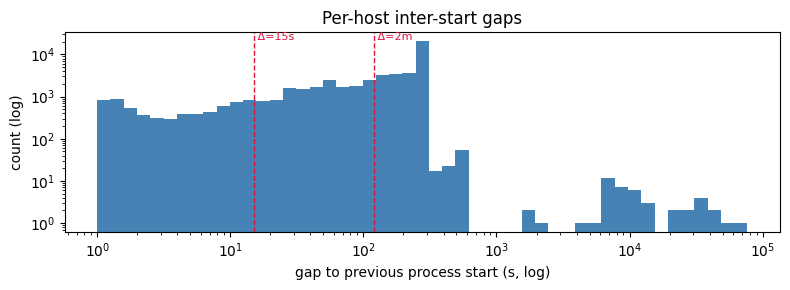

In [5]:
# ── Step 1: drop telemetry self-noise + derive the idle-gap threshold Δ ──────
# conhost.exe = console-allocation side effect (75% of rows, no behavioral signal).
# wintap/mergehelper/wintapsvcmgr = the WinTap collection agent observing itself
# (mergehelper alone formed a 21K-process / 596-hour blob on ACME-WS-PLU).
NOISE = {"conhost.exe", "mergehelper.exe", "wintap.exe", "wintapsvcmgr.exe"}

def prep(df):
    """Drop noise rows, parse start time, sort by (host, time)."""
    d = df[~df["process_name"].isin(NOISE)].copy()
    d["t"] = pd.to_numeric(d["process_started_seconds"], errors="coerce")
    d = d.dropna(subset=["t"]).sort_values(["hostname", "t"]).reset_index(drop=True)
    d["gap"] = d["t"] - d.groupby("hostname")["t"].shift(1)   # secs since prev proc on host
    return d

dtr = prep(df_train)
gaps = dtr["gap"].dropna()
gaps = gaps[gaps >= 0]
print("inter-start gap quantiles (minutes):")
for q in [0.5, 0.9, 0.99, 0.999]:
    print(f"  p{q*100:5.1f}: {gaps.quantile(q)/60:7.2f} min")

# Log-histogram of idle gaps. Two thresholds matter downstream:
#   Δ=2 min  -> best for the temporal-ONLY baseline (bursts must be self-contained)
#   Δ=15 s   -> backbone for the GRAPH sessionizer (strong edges do the stitching)
pos = gaps[gaps > 0]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(pos, bins=np.logspace(0, np.log10(pos.max()), 50), color="steelblue")
ax.set_xscale("log"); ax.set_yscale("log")
for lab, sec in [("Δ=15s", 15), ("Δ=2m", 120)]:
    ax.axvline(sec, ls="--", lw=1, color="crimson")
    ax.text(sec, ax.get_ylim()[1], f" {lab}", color="crimson", va="top", fontsize=8)
ax.set_xlabel("gap to previous process start (s, log)"); ax.set_ylabel("count (log)")
ax.set_title("Per-host inter-start gaps")
plt.tight_layout(); plt.show()

DELTA_MIN = 2   # temporal-only baseline threshold (enrichment-sweep winner)

In [6]:
# ── Step 2a (BASELINE): temporal-only burst sessions ─────────────────────────
def sessionize(d, delta_min=DELTA_MIN):
    """Start a new session whenever the per-host gap exceeds Δ. Assumes prep() ran."""
    new_burst = d["gap"].isna() | (d["gap"] > delta_min * 60)
    burst_idx = new_burst.groupby(d["hostname"]).cumsum().astype(int)
    d = d.copy()
    d["session_id"] = d["hostname"].astype(str) + "__" + burst_idx.astype(str)
    return d

dtr_base = sessionize(dtr, DELTA_MIN)
sizes = dtr_base.groupby("session_id").size()
red_sess = dtr_base.groupby("session_id")["red_team"].max()
print(f"BASELINE Δ = {DELTA_MIN} min (temporal only)")
print(f"sessions: {sizes.shape[0]:,} | median {sizes.median():.0f} | "
      f"p95 {sizes.quantile(.95):.0f} | max {sizes.max():,} | "
      f"singletons {(sizes == 1).sum():,}")
print(f"red sessions: {int((red_sess == 1).sum())} ({(red_sess == 1).mean():.3%})")

BASELINE Δ = 2 min (temporal only)
sessions: 31,412 | median 4 | p95 10 | max 2,024 | singletons 1,633
red sessions: 125 (0.398%)


In [7]:
# ── Step 2b (GRAPH): temporal backbone + parent + shared-rare-file edges ─────
from graph_sessions import (GraphSessionizer, TemporalChainEdges,
                            ParentChildEdges, SharedResourceEdges)

SV = "gdo168.llnl.gov/data/ACME4/stdview-20240819-20240923"
file_links = pd.read_parquet(f"{SV}/process_file.parquet",
                             columns=["pid_hash", "Hostname", "filename"])

GRAPH_DELTA_S = 15   # short backbone: strong edges stitch across longer pauses

def sessionize_graph(d):
    gs = GraphSessionizer([
        TemporalChainEdges("hostname", "t", GRAPH_DELTA_S),
        ParentChildEdges("pid_hash", "parent_pid_hash", max_children=25),
        SharedResourceEdges(file_links, ["Hostname", "filename"],
                            "pid_hash", max_degree=10),
    ], id_col="pid_hash")
    d = d.copy()
    d["session_id"] = gs.fit_transform(d)
    return d, gs.report_

dtr, report = sessionize_graph(dtr)
red_sess = dtr.groupby("session_id")["red_team"].max()
print("GRAPH sessionizer report:")
for k, v in report.items():
    print(f"  {k}: {v}")
print(f"  red sessions: {int((red_sess == 1).sum())} ({(red_sess == 1).mean():.3%})")
# max_component is the god-component canary — keep it ~1-2K, not 10K+

GRAPH sessionizer report:
  edges_per_type: {'temporal': 119072, 'parent': 9444, 'resource': 40985}
  n_nodes: 165222
  n_sessions: 44101
  median_component: 4.0
  p95_component: 5.0
  max_component: 1979
  singletons: 9540
  red sessions: 978 (2.218%)


## Embedding: ordered token co-occurrence → session vectors

1. **Tokens are args-aware:** `process_name|normalized_args` — paths/GUIDs/hex/numbers get
   placeholder-normalized; combos seen <50× fall back to the bare process name. This separates
   `powershell|<recon flags>` from everyday powershell without exploding the vocab (224 → ~290).
2. **Token embeddings** are learned self-supervised from the *ordered* session sequences:
   windowed co-occurrence → PPMI → TruncatedSVD (word2vec-style, no native build deps).
3. **Session vectors** = [rarity-weighted mean ⊕ max-pool] of token vectors ⊕ log-compressed
   numeric behavior aggregates. Rarity weighting (self-information) + max-pooling keep one
   suspicious process from being averaged away inside a big mixed session.

Ablation (proc-level, graph sessions): name-tokens/mean-pool → 43.4%/55.3% train, 6.3%/8.4%
test; **args-tokens/rarity-max pool → 46.5%/51.6% train, 7.8%/11.2% test** with the lowest
analyst workload. Labels are **not** used anywhere in fitting — only in the validation cells.

In [8]:
# ── Step 3: args-aware tokens + embeddings from ordered co-occurrence ────────
import re

EMB_DIM   = 24
WINDOW    = 3    # co-occurrence look-ahead within a session sequence
MIN_COUNT = 50   # name|args combos rarer than this fall back to the bare name

_path = re.compile(r"[a-z]:\\[^\s\"']*|\\\\[^\s\"']*|/[^\s\"']*")
_guid = re.compile(r"[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}")
_hex  = re.compile(r"\b[0-9a-f]{6,}\b")
_num  = re.compile(r"\b\d+\b")
_ws   = re.compile(r"\s+")

def norm_args(s):
    """Collapse volatile parts of a command line so recurring patterns share a token."""
    s = str(s).lower()
    s = _path.sub("<path>", s)
    s = _guid.sub("<guid>", s)
    s = _hex.sub("<hex>", s)
    s = _num.sub("<n>", s)
    return _ws.sub(" ", s).strip()[:120]

def fit_token_vocab(d, min_count=MIN_COUNT):
    name = d["process_name"].fillna("<na>").astype(str)
    raw = name + "|" + d["args"].map(norm_args)
    vc = raw.value_counts()
    keep = set(vc[vc >= min_count].index)
    final = raw.where(raw.isin(keep), name)        # rare combos -> bare name
    vmap = {t: i for i, t in enumerate(pd.Index(final.unique()))}
    vmap.setdefault("<unk>", len(vmap))
    return {"keep": keep, "map": vmap}

def add_tokens(d, vocab):
    name = d["process_name"].fillna("<na>").astype(str)
    raw = name + "|" + d["args"].map(norm_args)
    final = raw.where(raw.isin(vocab["keep"]), name)
    d = d.copy()
    d["ptok"] = final.map(vocab["map"]).fillna(vocab["map"]["<unk>"]).astype(int)
    return d

def build_proc_embeddings(d, vocab, emb_dim=EMB_DIM, window=WINDOW):
    """Windowed co-occurrence -> PPMI -> SVD. Returns L2-normalized (P, emb_dim) matrix."""
    P = len(vocab["map"])
    d = d.sort_values(["session_id", "t"])
    tok = d["ptok"].to_numpy()
    co = np.zeros((P, P), dtype=np.float64)
    for off in range(1, window + 1):
        # pair each token with the one `off` positions ahead in the SAME session
        nxt = d.groupby("session_id")["ptok"].shift(-off).to_numpy()
        m = ~np.isnan(nxt)
        a, b = tok[m], nxt[m].astype(int)
        np.add.at(co, (a, b), 1.0)
        np.add.at(co, (b, a), 1.0)
    co += 1e-9
    Pxy = co / co.sum()
    Px = Pxy.sum(1, keepdims=True)
    ppmi = np.maximum(np.log(Pxy / (Px * Px.T)), 0.0)
    emb = TruncatedSVD(n_components=min(emb_dim, P - 1), random_state=0).fit_transform(ppmi)
    return normalize(emb)

# vocab/embeddings/rarity are fit on TRAIN and reused for test
vocab = fit_token_vocab(dtr)
dtr = add_tokens(dtr, vocab)
proc_emb = build_proc_embeddings(dtr, vocab)
tok_freq = dtr["ptok"].value_counts(normalize=True).to_dict()   # rarity weights
print(f"token vocab: {len(vocab['map'])} | embedding matrix: {proc_emb.shape}")

token vocab: 288 | embedding matrix: (288, 24)


In [9]:
# ── Step 4: session features = [rarity-mean ⊕ max-pool] ⊕ behavior aggregates ──
NUM = ["reg_totals", "reg_writes", "Read_Events", "Write_Events", "Create_Events",
       "Delete_Events", "net_total_events", "net_total_size", "tcp_connect_count",
       "total_sigma_hits", "critical_num_sigma_hits", "high_num_sigma_hits",
       "lolbas_num_rows", "mitre_num_rows", "duration_seconds"]
NUM = [c for c in NUM if c in df_train.columns]

def session_features(d, scaler=None):
    """d must be prep()->sessionize()->add_tokens()'d. Returns (sessions, X, red, scaler)."""
    V = proc_emb[d["ptok"].to_numpy()]
    sid = d["session_id"].values

    # rarity-weighted mean: rare tokens dominate; common ones contribute little
    p = d["ptok"].map(tok_freq).fillna(min(tok_freq.values())).to_numpy()
    w = -np.log(np.clip(p, 1e-9, 1.0))                       # self-information
    wv = pd.DataFrame(V * w[:, None], index=d.index).assign(s=sid).groupby("s").sum()
    wsum = pd.Series(w, index=d.index).groupby(sid).sum()
    rmean = wv.to_numpy() / np.maximum(wsum.to_numpy(), 1e-9)[:, None]

    # max-pool: a single extreme token survives any session size
    vmax = pd.DataFrame(V, index=d.index).assign(s=sid).groupby("s").max()

    num = d[NUM].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    num["s"] = sid
    agg = num.groupby("s").sum()
    agg["n_proc"] = d.groupby(sid).size()
    agg["n_uniq"] = d.groupby(sid)["ptok"].nunique()
    agg = np.log1p(agg.clip(lower=0))                        # tame heavy tails

    sessions = vmax.index
    raw = np.hstack([rmean, vmax.to_numpy(), agg.loc[sessions].to_numpy()])
    if scaler is None:
        scaler = StandardScaler().fit(raw)
    X = scaler.transform(raw)
    red = d.groupby(sid)["red_team"].max().loc[sessions].to_numpy().astype(int)
    return sessions, X, red, scaler

sess_tr, X_tr, red_tr, scaler = session_features(dtr)
print(f"train session feature matrix: {X_tr.shape} | red sessions: {int(red_tr.sum())}")

train session feature matrix: (44101, 65) | red sessions: 978


In [10]:
df_acme

,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolbas_mitre,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team
0,CF830E1523374BE7F0E5F91F7936443E,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,1900,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
1,42DEC9F24F7D08578FB30A75AF68C661,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-DXJ,3748,wmic.exe,1,computersystem get dnshostname /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
2,A4207647384708DBA1C4552112C948F9,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,5268,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
3,D7D35ACED1E249E503B9049D2F9599BD,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,3056,wmic.exe,1,computersystem get domain /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
4,224B925BA2818C792E07DE5FFD088CCC,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,5160,wmic.exe,1,os get caption /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668332,EEFC0AA67ACE54455AE63E69B03B9A60,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,11480,firefox.exe,1,-contentproc --channel=10748 -childid 595 -isf...,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668333,8AF50B940C8D6F8BE4AB6619811FB954,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,6240,wintapsvcmgr.exe,1,healthcheck,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668334,C508BC0D59E15B2F08B144F510030EB5,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,8304,dismhost.exe,1,{5a8e0c33-2aec-4972-9558-20b408b28af5},1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668335,1BD3897F9FB25164AAB6CF4FD3A1B7D7,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,8560,firefox.exe,1,-contentproc --channel=15348 -childid 1998 -is...,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0


=== TRAIN graph sessions ===
sessions=44,101  clusters=772  noise=13,224  red_sessions=978
hot clusters (>=5x): 25 | session recall=74.4% | PROC recall=46.5% purity=51.6% flagged=2,231/165,222 procs
         size  red      rate  enrichment
cluster                                 
214        39   39  1.000000   45.093047
277        16   16  1.000000   45.093047
86         19   19  1.000000   45.093047
213       107  105  0.981308   44.250186
209        16   15  0.937500   42.274732
203        30   28  0.933333   42.086844


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


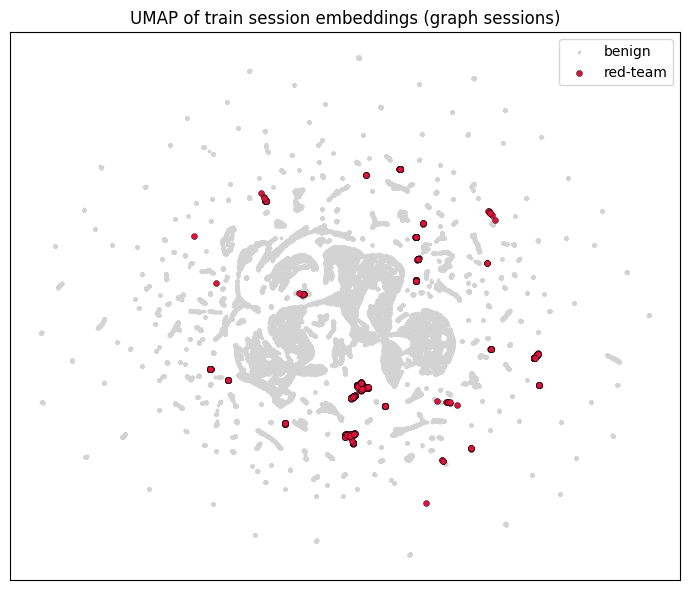

In [11]:
# ── Step 5: cluster + validate that red-team sessions surface as anomalies ────
def cluster_and_report(d, sessions, X, red, title, min_cluster_size=15, min_samples=5):
    labels = HDBSCAN(min_cluster_size=min_cluster_size,
                     min_samples=min_samples, copy=True).fit_predict(X)
    base = red.mean()
    g = (pd.DataFrame({"cluster": labels, "red": red})
         .groupby("cluster")["red"].agg(size="size", red="sum", rate="mean"))
    g["enrichment"] = g["rate"] / base
    g = g.sort_values("rate", ascending=False)

    hot = g[(g.index >= 0) & (g["enrichment"] >= 5)].index
    in_hot = np.isin(labels, hot)
    # session-level
    s_recall = red[in_hot].sum() / max(red.sum(), 1)
    # process-level (the honest metric: how much red ACTIVITY is in flagged sessions,
    # and how much benign activity an analyst would wade through)
    flagged = set(np.asarray(sessions)[in_hot])
    in_flag = d["session_id"].isin(flagged)
    red_proc = d["red_team"] == 1
    p_recall = (red_proc & in_flag).sum() / max(red_proc.sum(), 1)
    p_purity = red_proc[in_flag].mean() if in_flag.any() else 0.0
    print(f"=== {title} ===")
    print(f"sessions={len(red):,}  clusters={int((g.index >= 0).sum())}  "
          f"noise={int((labels == -1).sum()):,}  red_sessions={int(red.sum())}")
    print(f"hot clusters (>=5x): {len(hot)} | session recall={s_recall:.1%} | "
          f"PROC recall={p_recall:.1%} purity={p_purity:.1%} "
          f"flagged={int(in_flag.sum()):,}/{len(d):,} procs")
    print(g.head(6).to_string())
    return labels

labels_tr = cluster_and_report(dtr, sess_tr, X_tr, red_tr, "TRAIN graph sessions")

# UMAP projection for a visual read on separation (red sessions overlaid)
proj = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=0).fit_transform(X_tr)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(proj[red_tr == 0, 0], proj[red_tr == 0, 1], s=3, c="lightgray", label="benign")
ax.scatter(proj[red_tr == 1, 0], proj[red_tr == 1, 1], s=18, c="crimson",
           edgecolor="k", linewidth=0.3, label="red-team")
ax.set_title("UMAP of train session embeddings (graph sessions)")
ax.legend(); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

<InteractiveFigure width=100% height=800>
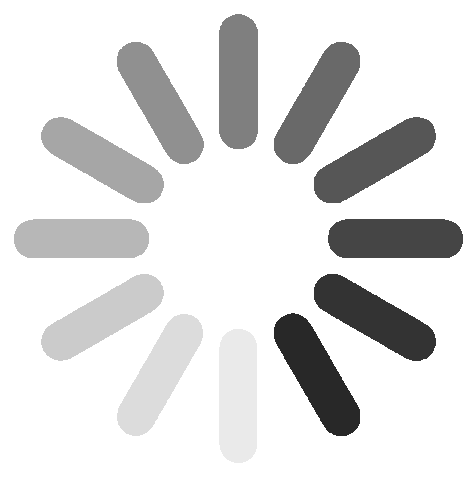

In [13]:
import datamapplot

stringify_red_tr = red_tr.astype(str)
color_map = {"0": "lightgray", "1": "red"}
plot = datamapplot.create_interactive_plot(
    proj, 
    stringify_red_tr, 
    hover_text = stringify_red_tr, 
    label_color_map=color_map)
plot

In [ ]:
# ── Step 6: apply the SAME fitted pipeline to the held-out TEST split ─────────
# Reuse the train-fit vocab, token embeddings, rarity weights, and feature scaler;
# only the unsupervised clustering is re-fit on test (no labels fit anything).
# NOTE: test = the EARLIER period (Jun-Sep 9) and contains the main attack
# campaign; its red activity is chunkier (~14 procs/red session vs ~2.6 in train).
dte, report_te = sessionize_graph(prep(df_test))
dte = add_tokens(dte, vocab)
print(f"test max_component: {report_te['max_component']:,} "
      f"(god-component canary)\n")
sess_te, X_te, red_te, _ = session_features(dte, scaler=scaler)
labels_te = cluster_and_report(dte, sess_te, X_te, red_te, "TEST graph sessions")

Gold

In [16]:
gold = pd.read_parquet("gdo168.llnl.gov/data/ACME4/gold/train-process_uber_summary.parquet")

In [17]:
gold

,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolbas_mitre,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team
0,CF830E1523374BE7F0E5F91F7936443E,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,1900,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
1,42DEC9F24F7D08578FB30A75AF68C661,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-DXJ,3748,wmic.exe,1,computersystem get dnshostname /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
2,A4207647384708DBA1C4552112C948F9,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,5268,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
3,D7D35ACED1E249E503B9049D2F9599BD,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,3056,wmic.exe,1,computersystem get domain /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
4,224B925BA2818C792E07DE5FFD088CCC,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,5160,wmic.exe,1,os get caption /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668332,EEFC0AA67ACE54455AE63E69B03B9A60,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,11480,firefox.exe,1,-contentproc --channel=10748 -childid 595 -isf...,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668333,8AF50B940C8D6F8BE4AB6619811FB954,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,6240,wintapsvcmgr.exe,1,healthcheck,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668334,C508BC0D59E15B2F08B144F510030EB5,windows,fe437745-98c3-4d17-8e19-b8ba145caced,1,ACME-DC1,8304,dismhost.exe,1,{5a8e0c33-2aec-4972-9558-20b408b28af5},1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
668335,1BD3897F9FB25164AAB6CF4FD3A1B7D7,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,8560,firefox.exe,1,-contentproc --channel=15348 -childid 1998 -is...,1,...,None,None,NaN,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
